## Intensity simulations


Angular RMSD + mean charge

I_1.00e+10 → Angular: 19.47°, Charge: 0.465±0.061
I_1.44e+10 → Angular: 18.26°, Charge: 0.622±0.072
I_2.07e+10 → Angular: 17.05°, Charge: 0.801±0.078
I_2.98e+10 → Angular: 16.09°, Charge: 1.013±0.099
I_4.28e+10 → Angular: 14.76°, Charge: 1.323±0.080
I_6.16e+10 → Angular: 13.49°, Charge: 1.575±0.073
I_8.86e+10 → Angular: 12.12°, Charge: 1.842±0.077
I_1.27e+11 → Angular: 11.07°, Charge: 2.096±0.061
I_1.83e+11 → Angular: 10.07°, Charge: 2.380±0.065
I_2.64e+11 → Angular: 8.86°, Charge: 2.710±0.049
I_3.79e+11 → Angular: 7.62°, Charge: 3.007±0.039
I_5.46e+11 → Angular: 6.18°, Charge: 3.303±0.047
I_7.85e+11 → Angular: 5.24°, Charge: 3.510±0.040
I_1.13e+12 → Angular: 4.51°, Charge: 3.638±0.033
I_1.62e+12 → Angular: 4.02°, Charge: 3.703±0.029
I_2.34e+12 → Angular: 3.69°, Charge: 3.728±0.031
I_3.36e+12 → Angular: 3.30°, Charge: 3.720±0.044
I_4.83e+12 → Angular: 2.98°, Charge: 3.732±0.046
I_6.95e+12 → Angular: 2.58°, Charge: 3.735±0.043
I_1.00e+13 → Angular: 2.20°, Charge: 3.739±0.038
I_1.00e+10 

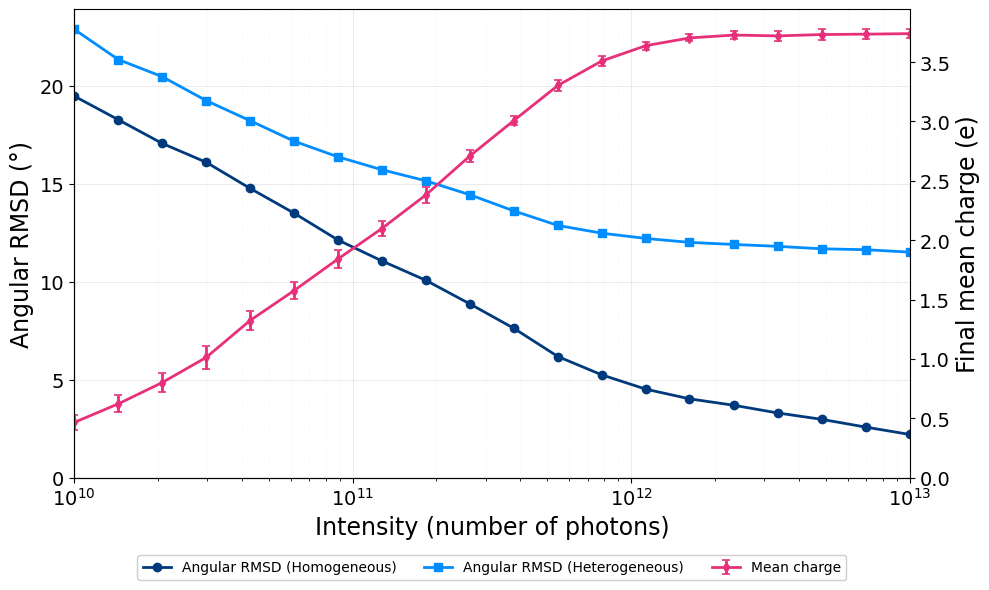

In [ ]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import MDAnalysis as mda

# Paths to both datasets
homogeneous_folder = "/home/wilma/harryshouse/output_data/intensityvar_homogen"
heterogeneous_folder = "/home/wilma/harryshouse/output_data/intensityvar_heterogen"

SELECT_HEAVY = True  # Don't include hydrogens

#load data
def load_from_h5(rep_path):
    h5_file = os.path.join(rep_path, "results.h5")
    gro_file = os.path.join(rep_path, "conf.gro")

    if not os.path.exists(h5_file) or not os.path.exists(gro_file):
        return None, None

    try:
        with h5py.File(h5_file, 'r') as f:
            velf = f["final_velocity"][:]

            #take final value of mean charge if it exists
            if "mean_charge" in f:
                charge_series = f["mean_charge"][:]
                charge = charge_series[-1] if len(charge_series) > 0 else None
            else:
                charge = None

        if SELECT_HEAVY:  # No hydrogens
            u = mda.Universe(gro_file)
            heavy_idx = u.select_atoms("not name H*").indices
            velf = velf[heavy_idx]

        return velf, charge

    except Exception as e:
        print(f"[warn] {rep_path}: {e}")
        return None, None

#function to compute angular rmsd and mean charge for each intensity level
def compute_angular_variability_and_charge(sim_output):

    intensity_dirs = sorted(
        [d for d in os.listdir(sim_output) if d.startswith("I_")],
        key=lambda d: float(d[2:])
    )

    intensities = []
    angular_stds = []
    mean_charges = []
    std_charges = []

    for idir in intensity_dirs:
        intensity = float(idir[2:])
        ipath = os.path.join(sim_output, idir)

        all_vels = []
        all_charges = []

        for rep in sorted(os.listdir(ipath)):
            rep_path = os.path.join(ipath, rep)
            if not os.path.isdir(rep_path):
                continue

            v, c = load_from_h5(rep_path)
            if v is not None:
                all_vels.append(v)
            if c is not None:
                all_charges.append(c) 

        if len(all_vels) < 2: #make sure to only calculate if we have at least 2 replicas
            print(f"[skip] {idir}: only {len(all_vels)} replica(s)")
            continue

        # angular rmsd calculation

        V = np.array(all_vels) 

        # Normalize velocity vectors
        norms = np.linalg.norm(V, axis=2, keepdims=True)
        norms[norms == 0] = 1.0
        V_unit = V / norms

        # Compute mean unit vector
        mean_V = np.mean(V_unit, axis=0)
        mean_norms = np.linalg.norm(mean_V, axis=1)

        # Filter out atoms with no direction
        valid = mean_norms > 1e-8
        mean_unit = np.zeros_like(mean_V)
        mean_unit[valid] = mean_V[valid] / mean_norms[valid, None]

        # Compute angles
        cos_theta = np.sum(V_unit * mean_unit[None, :, :], axis=2)
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        angles = np.degrees(np.arccos(cos_theta))

        # compute the rmsd
        angular_std_per_atom = np.std(angles, axis=0)
        mean_angular_std = np.mean(angular_std_per_atom[valid])

        # mean charge
        if len(all_charges) > 0:
            mean_charge = np.mean(all_charges)
            std_charge = np.std(all_charges)
        else:
            mean_charge = 0.0
            std_charge = 0.0

        intensities.append(intensity)
        angular_stds.append(mean_angular_std)
        mean_charges.append(mean_charge)
        std_charges.append(std_charge)

        print(f"{idir} → Angular: {mean_angular_std:.2f}°, Charge: {mean_charge:.3f}±{std_charge:.3f}")

    return (np.array(intensities), np.array(angular_stds),
            np.array(mean_charges), np.array(std_charges))


# run rmsd calculation for both datasets
intensities_homo, angular_std_homo, charges_homo, std_charges_homo = \
    compute_angular_variability_and_charge(homogeneous_folder)

intensities_hetero, angular_std_hetero, charges_hetero, std_charges_hetero = \
    compute_angular_variability_and_charge(heterogeneous_folder)


# plot angular rmsd + mean charge
fig, ax1 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')

# Angular RMSD - Homogeneous
line1, = ax1.plot(intensities_homo, angular_std_homo, 'o-', color='#003a7d',
                  linewidth=2, markersize=6, label='Angular RMSD (Homogeneous)')

# Angular RMSD - Heterogeneous
line2, = ax1.plot(intensities_hetero, angular_std_hetero, 's-', color="#008dff",
                  linewidth=2, markersize=6, label='Angular RMSD (Heterogeneous)')

ax1.set_xlabel('Intensity (number of photons)', fontsize=17)
ax1.set_ylabel('Angular RMSD (°)', fontsize=17)
ax1.tick_params(axis='both', labelsize=14)
ax1.set_xscale('log')
ax1.set_xlim(1e10, 1e13)
ax1.grid(True, which='major', linestyle='-', alpha=0.15, color='gray')
ax1.grid(True, which='minor', linestyle=':', alpha=0.08, color='gray')
ax1.spines[['top', 'right']].set_visible(False)

# Mean charge on secondary y-axis
ax2 = ax1.twinx()
line3 = ax2.errorbar(intensities_homo, charges_homo, yerr=std_charges_homo,
                     fmt='d-', color="#E8307A", linewidth=2,
                     markersize=5, capsize=3, capthick=1.2, label='Mean charge')
ax2.set_ylabel('Final mean charge (e)', fontsize=17)
ax2.tick_params(axis='y', labelsize=14)

# Combined legend below the plot
handles = [line1, line2, line3]
labels = ['Angular RMSD (Homogeneous)', 'Angular RMSD (Heterogeneous)', 'Mean charge']
ax1.legend(handles, labels, loc='upper center',
           bbox_to_anchor=(0.5, -0.15), ncol=3,
           fontsize=10, framealpha=0.95, edgecolor='#cccccc')

#plt.title('Angular RMSD and Mean Charge vs Intensity', fontsize=13, pad=12)
plt.tight_layout()

# Re-enforce y-axis limits after tight_layout to prevent rescaling
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

#plt.savefig("angular_rmsd_both_datasets_with_charge.png", dpi=300, bbox_inches='tight') #save fig
plt.show()


## Pulse duration

dur_10fs → Angular RMSD = 10.28°
dur_20fs → Angular RMSD = 11.34°
dur_30fs → Angular RMSD = 11.95°
dur_40fs → Angular RMSD = 12.18°
dur_50fs → Angular RMSD = 12.22°
dur_60fs → Angular RMSD = 12.36°
dur_70fs → Angular RMSD = 12.49°
[warn] /home/wilma/harryshouse/output_data/duration_sweep_2MS2/dur_80fs/rep_045: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/wilma/harryshouse/output_data/duration_sweep_2MS2/dur_80fs/rep_045/results.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
dur_80fs → Angular RMSD = 12.93°
[warn] /home/wilma/harryshouse/output_data/duration_sweep_2MS2/dur_90fs/rep_004: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/wilma/harryshouse/output_data/duration_sweep_2MS2/dur_90fs/rep_004/results.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
[warn] /home/wilma/harryshouse/output_data/duration_sweep_2MS2/dur_90fs/rep_010: [Errno 2] Una

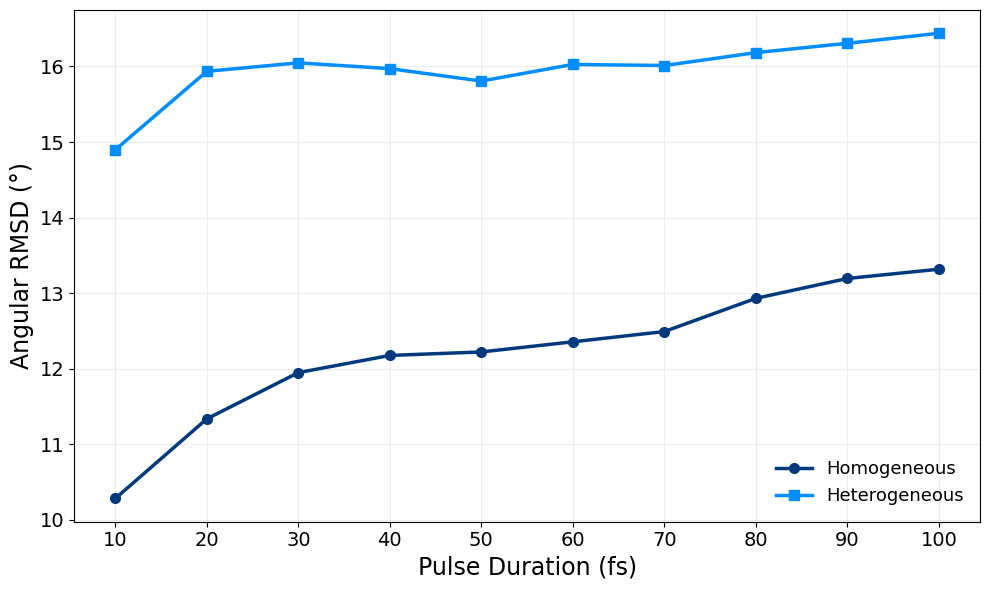

In [18]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import MDAnalysis as mda
#paths
homogeneous_folder = "/home/wilma/harryshouse/output_data/duration_sweep_2MS2"

heterogeneous_folder = "/home/wilma/harryshouse/output_data/diff_structures_duration"

SELECT_HEAVY = True  # Exclude hydrogens


#load data
def load_from_h5(rep_path):

    h5_file = os.path.join(rep_path, "results.h5")

    if os.path.exists(os.path.join(rep_path, "conf.gro")):

      gro_file = os.path.join(rep_path, "conf.gro")

    elif os.path.exists(os.path.join(rep_path, "equilibrated.gro")):

      gro_file = os.path.join(rep_path, "equilibrated.gro")

    else:

      return None

    try:

        with h5py.File(h5_file, 'r') as f:

            velf = f["final_velocity"][:]

        # Remove hydrogens
        if SELECT_HEAVY:

            u = mda.Universe(gro_file)

            heavy_idx = u.select_atoms(
                "not name H*"
            ).indices

            velf = velf[heavy_idx]

        return velf

    except Exception as e:

        print(f"[warn] {rep_path}: {e}")

        return None


# ANGULAR RMSD CALCULATION
def compute_angular_variability(sim_output):

    duration_dirs = sorted(
        [d for d in os.listdir(sim_output)
         if d.startswith("dur_")],

        key=lambda d: float(
            d.split("_")[1].replace("fs", "")
        )
    )

    durations = []

    angular_stds = []

    for idir in duration_dirs:

        duration = float(
            idir.split("_")[1].replace("fs", "")
        )

        ipath = os.path.join(sim_output, idir)

        all_vels = []

        for rep in sorted(os.listdir(ipath)):

            rep_path = os.path.join(ipath, rep)

            if not os.path.isdir(rep_path):

                continue

            v = load_from_h5(rep_path)

            if v is not None:

                all_vels.append(v)

        # Need at least 2 replicas
        if len(all_vels) < 2:

            print(
                f"[skip] {idir}: "
                f"only {len(all_vels)} replica(s)"
            )

            continue


    
        V = np.array(all_vels)

        # Normalize velocity vectors
        norms = np.linalg.norm(
            V,
            axis=2,
            keepdims=True
        )

        norms[norms == 0] = 1.0

        V_unit = V / norms

        # Mean direction
        mean_V = np.mean(V_unit, axis=0)

        mean_norms = np.linalg.norm(
            mean_V,
            axis=1
        )

        # Avoid zero vectors
        valid = mean_norms > 1e-8

        mean_unit = np.zeros_like(mean_V)

        mean_unit[valid] = (
            mean_V[valid] /
            mean_norms[valid, None]
        )

        # Compute angles
        cos_theta = np.sum(
            V_unit * mean_unit[None, :, :],
            axis=2
        )

        cos_theta = np.clip(
            cos_theta,
            -1.0,
            1.0
        )

        angles = np.degrees(
            np.arccos(cos_theta)
        )

        # RMSD
        angular_std_per_atom = np.std(
            angles,
            axis=0
        )

        mean_angular_std = np.mean(
            angular_std_per_atom[valid]
        )

        durations.append(duration)

        angular_stds.append(mean_angular_std)

        print(
            f"{idir} → "
            f"Angular RMSD = "
            f"{mean_angular_std:.2f}°"
        )

    return (
        np.array(durations),
        np.array(angular_stds)
    )


#run calculations
durations_homo, angular_std_homo = \
    compute_angular_variability(
        homogeneous_folder
    )

durations_hetero, angular_std_hetero = \
    compute_angular_variability(
        heterogeneous_folder
    )


#plot
fig, ax = plt.subplots(figsize=(10, 6))

# Homogeneous
ax.plot(
    durations_homo,
    angular_std_homo,
    'o-',
    color='#003a7d',
    linewidth=2.5,
    markersize=7,
    label='Homogeneous'
)

# Heterogeneous
ax.plot(
    durations_hetero,
    angular_std_hetero,
    's-',
    color='#008dff',
    linewidth=2.5,
    markersize=7,
    label='Heterogeneous'
)

# Labels
ax.set_xlabel(
    'Pulse Duration (fs)',
    fontsize=17
)

ax.set_ylabel(
    'Angular RMSD (°)',
    fontsize=17
)

# Ticks
ax.tick_params(
    axis='both',
    labelsize=14
)

# Grid
ax.grid(
    True,
    which='major',
    linestyle='-',
    alpha=0.15,
    color='gray'
)

#duration ticks
all_durations = np.concatenate(
    [durations_homo, durations_hetero]
)

ax.set_xticks(
    sorted(set(all_durations))
)

# Legend
ax.legend(
    fontsize=13,
    frameon=False
)

#title
# ax.set_title(
#     'Angular RMSD vs Pulse Duration',
#     fontsize=15
# )

plt.tight_layout()

# Save figure
plt.savefig(
     "angular_rmsd_vs_duration.svg",
     dpi=300,
     bbox_inches='tight'
 )


plt.show()